In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
best_trial = 86
con_mats_path = f"artifacts_max/trial_{best_trial}/confusion_matrices.npy"
con_mats = np.load(con_mats_path)
con_mats

array([[[ 3,  1],
        [ 1,  9]],

       [[ 1,  3],
        [ 0,  9]],

       [[ 3,  1],
        [ 1,  8]],

       [[ 1,  2],
        [ 1,  9]],

       [[ 3,  0],
        [ 0, 10]]])

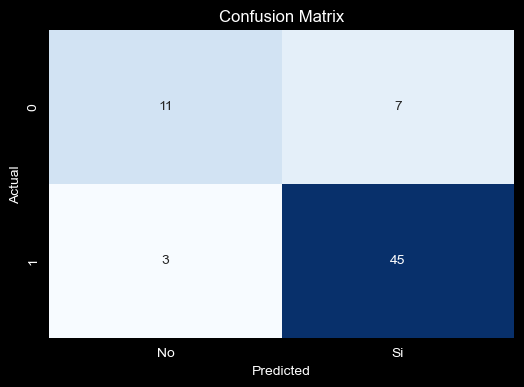

In [5]:
sum_con_mat = np.sum(con_mats, axis=0)
# Plot the summed confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(sum_con_mat, annot=True, fmt='d', cmap='Blues', cbar=False,
            yticklabels=['0', '1'],
            xticklabels=['No', 'Si'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [6]:
best_trial = 33
con_mats_path = f"artifacts_max/trial_{best_trial}/confusion_matrices.npy"
con_mats = np.load(con_mats_path)
con_mats

array([[[3, 1],
        [2, 8]],

       [[4, 0],
        [1, 8]],

       [[2, 2],
        [1, 8]],

       [[3, 0],
        [1, 9]],

       [[1, 2],
        [1, 9]]])

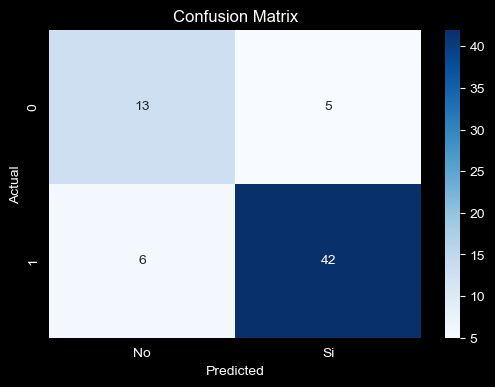

In [8]:
sum_con_mat = np.sum(con_mats, axis=0)
# Plot the summed confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(sum_con_mat, annot=True, fmt='d', cmap='Blues',# cbar=False,
            yticklabels=['0', '1'],
            xticklabels=['No', 'Si'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# AUC Optimized

In [17]:
best_trial = 42
con_mats_path = f"artifacts_max/trial_{best_trial}/confusion_matrices.npy"
con_mats = np.load(con_mats_path)
con_mats

array([[[ 0,  4],
        [ 0, 10]],

       [[ 0,  4],
        [ 0,  9]],

       [[ 2,  2],
        [ 0,  9]],

       [[ 3,  0],
        [ 1,  9]],

       [[ 3,  0],
        [ 4,  6]]])

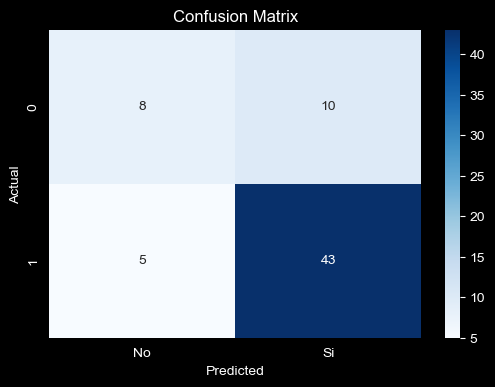

In [18]:
sum_con_mat = np.sum(con_mats, axis=0)
# Plot the summed confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(sum_con_mat, annot=True, fmt='d', cmap='Blues',# cbar=False,
            yticklabels=['0', '1'],
            xticklabels=['No', 'Si'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Maximize AUC, Save the best F1 🤷‍♂️

In [8]:
best_trial = 44
con_mats_path = f"artifacts_max/trial_{best_trial}/confusion_matrices.npy"
con_mats = np.load(con_mats_path)
con_mats

array([[[3, 1],
        [1, 9]],

       [[3, 1],
        [1, 8]],

       [[3, 1],
        [2, 7]],

       [[1, 2],
        [1, 9]],

       [[3, 0],
        [1, 9]]])

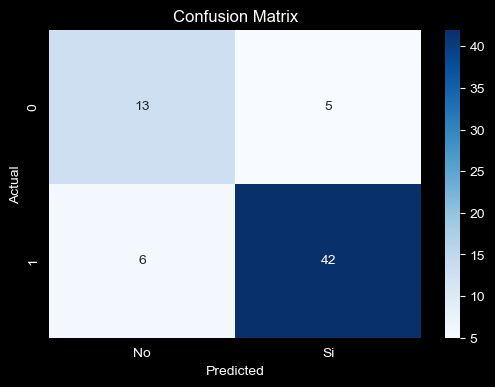

In [9]:
sum_con_mat = np.sum(con_mats, axis=0)
# Plot the summed confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(sum_con_mat, annot=True, fmt='d', cmap='Blues',# cbar=False,
            yticklabels=['0', '1'],
            xticklabels=['No', 'Si'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Ohne Holes

In [21]:
best_trial = 59
con_mats_path = f"artifacts_max/trial_{best_trial}/confusion_matrices.npy"
con_mats = np.load(con_mats_path)
con_mats

array([[[ 2,  2],
        [ 0, 10]],

       [[ 4,  0],
        [ 1,  8]],

       [[ 2,  2],
        [ 1,  8]],

       [[ 3,  0],
        [ 1,  9]],

       [[ 2,  1],
        [ 2,  8]]])

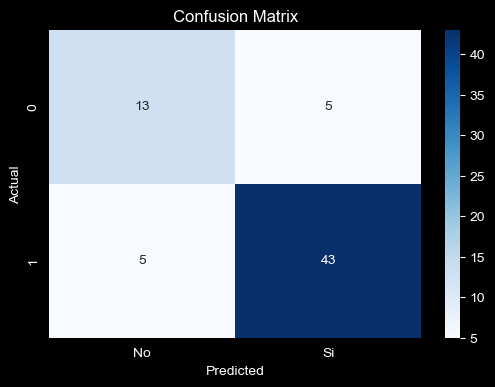

In [22]:
sum_con_mat = np.sum(con_mats, axis=0)
# Plot the summed confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(sum_con_mat, annot=True, fmt='d', cmap='Blues',# cbar=False,
            yticklabels=['0', '1'],
            xticklabels=['No', 'Si'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [24]:
import numpy as np
import pandas as pd
import os

def analyze_best_trials(trial_numbers, artifacts_base_dir="artifacts_max"):
    """
    Analyzes error consistency across multiple Optuna trials.

    Args:
        trial_numbers (list): List of trial numbers to analyze (e.g., [43, 12, 5]).
        artifacts_base_dir (str): Path to the folder containing trial subfolders.

    Returns:
        pd.DataFrame: A dataframe containing the error analysis, sorted by
                      'Error Count' (descending).
    """
    # Dictionary to aggregate results:
    # { file_id: { 'count': int, 'pdl': str, 'gt': int, 'preds': list } }
    aggregated_errors = {}

    print(f"Analyzing trials: {trial_numbers}...\n")

    for trial in trial_numbers:
        # 1. Construct Paths
        trial_dir = os.path.join(artifacts_base_dir, f"trial_{trial}")

        # Check if files exist
        if not os.path.exists(trial_dir):
            print(f"Warning: Directory not found for trial {trial}, skipping.")
            continue

        try:
            # 2. Load Data (Allow pickle for ragged arrays)
            pdls = np.load(os.path.join(trial_dir, "pdl1_status.npy"), allow_pickle=True)
            ground_truths = np.load(os.path.join(trial_dir, "ground_truths.npy"), allow_pickle=True)
            preds = np.load(os.path.join(trial_dir, "predictions.npy"), allow_pickle=True)
            file_ids = np.load(os.path.join(trial_dir, "file_ids.npy"), allow_pickle=True)
        except Exception as e:
            print(f"Error loading files for trial {trial}: {e}")
            continue

        # 3. Iterate through folds (outer list)
        for fold_idx in range(len(preds)):
            fold_preds = preds[fold_idx]
            fold_gt = ground_truths[fold_idx]
            fold_ids = file_ids[fold_idx]
            fold_pdls = pdls[fold_idx]

            # 4. Iterate through samples (inner arrays)
            for i in range(len(fold_preds)):
                fid = fold_ids[i]
                prediction = fold_preds[i]
                truth = fold_gt[i]
                pdl = fold_pdls[i]

                # Check for Mismatch
                if prediction != truth:
                    if fid not in aggregated_errors:
                        # Initialize entry
                        aggregated_errors[fid] = {
                            'Error Count': 0,
                            'PD-L1 Status': pdl,
                            'Ground Truth': truth,
                            'Wrong Predictions': []
                        }

                    # Update entry
                    aggregated_errors[fid]['Error Count'] += 1
                    aggregated_errors[fid]['Wrong Predictions'].append(f"T{trial}:{prediction}")

    # 5. Convert to DataFrame for nice visualization
    if not aggregated_errors:
        print("No errors found across these trials!")
        return pd.DataFrame()

    df = pd.DataFrame.from_dict(aggregated_errors, orient='index')

    # Add index as a column named 'File ID'
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'File ID'}, inplace=True)

    # Sort by 'Error Count' descending (most frequent errors first)
    df = df.sort_values(by='Error Count', ascending=False).reset_index(drop=True)

    return df

# Provide the best 3 trial numbers here
best_trials = [59,92,47]

# Run analysis
error_df = analyze_best_trials(best_trials)

# Display results
print(f"Found {len(error_df)} unique samples that were misclassified in at least one trial.")
print("-" * 80)
# Showing top 20 most frequent errors
print(error_df.to_string())

# Optionally save to CSV
error_df.to_csv("error_analysis_summary.csv", index=False)

Analyzing trials: [59, 92, 47]...

Found 20 unique samples that were misclassified in at least one trial.
--------------------------------------------------------------------------------
       File ID  Error Count PD-L1 Status  Ground Truth      Wrong Predictions
0    23-I-5775            3          0.8             0  [T59:1, T92:1, T47:1]
1    19-I-5057            3          0.2             0  [T59:1, T92:1, T47:1]
2    24-I-3388            3         0.01             0  [T59:1, T92:1, T47:1]
3    18-I-3503            3            0             0  [T59:1, T92:1, T47:1]
4    20-I-5083            2         0.03             1         [T59:0, T47:0]
5    17-I-9752            1         0.01             0                [T59:1]
6    20-I-4670            1         0.02             1                [T59:0]
7    20-I-5142            1         0.55             1                [T59:0]
8    20-I-7995            1            0             1                [T59:0]
9    21-I-4000            1      